# Solutions · 11 · High-pressure phase equilibria

Worked solutions to the exercises of [notebook 11](../notebooks/11_high_pressure_phase_equilibria.ipynb). Try each exercise
yourself before reading its solution - the learning happens in the attempt. Solutions are one way to
answer each question; other correct approaches exist.

In [1]:
try:                      # on Google Colab (or anywhere engthermo is missing): install it from GitHub
    import engthermo
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engthermo"], check=True)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from engthermo import eos, vapor, vle
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

def heading(text):
    print(f"\n{text}\n" + "=" * len(text))

## Exercise 1

A CO2 capture unit compresses a gas of 90 % CO2 and 10 % N2 at 30 degC. Find the bubble and dew pressures of this mixture with the PR equation (try k12 = 0 and k12 = -0.02) - can it be liquefied at 30 degC at all? Compare with pure CO2.

In [2]:
for T_C in (30, 20, 0, -20):
    T = T_C + 273.15
    line = f"{T_C:4d} degC: pure CO2 saturates at {vapor.eos_psat('pr', 'CO2', T)['p_sat']/1e5:5.1f} bar; 90/10 CO2/N2 -> "
    for kij in (0.0, -0.02):
        k = [[0, kij], [kij, 0]]
        try:
            line += f"k12 = {kij}: bubble {vle.eos_bubble_P('pr', ['CO2', 'N2'], [0.9, 0.1], T, kij=k)['p']/1e5:5.1f} bar"
        except ValueError:
            line += f"k12 = {kij}: no bubble point"
        try:
            line += f", dew {vle.eos_dew_P('pr', ['CO2', 'N2'], [0.9, 0.1], T, kij=k)['p']/1e5:5.1f} bar;  "
        except ValueError:
            line += ", no dew point;  "
    print(line)

  30 degC: pure CO2 saturates at  72.2 bar; 90/10 CO2/N2 -> k12 = 0.0: no bubble point, no dew point;  k12 = -0.02: no bubble point, no dew point;  


  20 degC: pure CO2 saturates at  57.4 bar; 90/10 CO2/N2 -> k12 = 0.0: bubble  72.1 bar, no dew point;  k12 = -0.02: bubble  70.8 bar, no dew point;  


   0 degC: pure CO2 saturates at  34.8 bar; 90/10 CO2/N2 -> k12 = 0.0: bubble  81.9 bar, dew  40.7 bar;  k12 = -0.02: bubble  79.8 bar, dew  40.7 bar;  
 -20 degC: pure CO2 saturates at  19.5 bar; 90/10 CO2/N2 -> k12 = 0.0: bubble  74.8 bar, dew  22.4 bar;  k12 = -0.02: bubble  71.4 bar, dew  22.3 bar;  


At 30 degC the equation finds neither a bubble nor a dew point: with 10 % nitrogen - a gas far above its own
critical temperature that does not want to be in a liquid - the mixture cannot be liquefied at that
temperature at all, whereas pure CO$_2$ liquefies at 72 bar. From 20 degC downwards the mixture has a bubble
point, but at 70-80 bar - far above pure CO$_2$'s saturation pressure at the same temperature. The interaction parameter
shifts the pressures by a few percent and hardly changes the picture. Liquefying a CO$_2$ stream for transport
therefore means removing the nitrogen or cooling well below ambient - a cost that CO$_2$ purity specifications
in capture projects are written around. (Near the critical region the PR equation with k12 = 0 is only
qualitative; the reference mixture model puts the bubble point at 82 bar at 0 degC and still finds one at 20 degC.)

## Exercise 2

For the natural gas of the notebook, plot the dew-point pressure against temperature from 230 to 300 K (the 'dew-point curve'). A pipeline operates at 70 bar: down to what temperature does the gas stay dry?

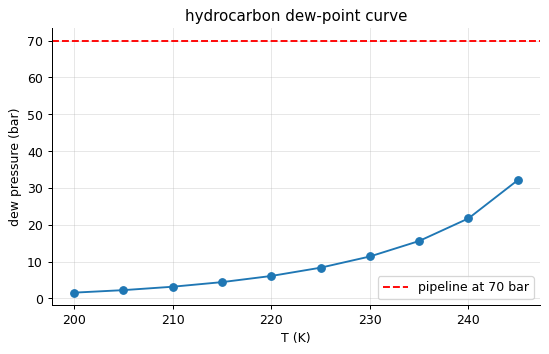

dew pressures 1.6-32.1 bar between 200 and 245 K; no dew point above the cricondentherm


In [3]:
gas = ["methane", "ethane", "propane", "n-butane"]
y = [0.90, 0.06, 0.03, 0.01]
Ts = np.arange(200, 251, 5.0)
p_dew = []
for T in Ts:
    try:
        p_dew.append(vle.eos_dew_P("pr", gas, y, T)["p"] / 1e5)
    except ValueError:
        p_dew.append(np.nan)
plt.plot(Ts, p_dew, "o-"); plt.axhline(70, color="r", ls="--", label="pipeline at 70 bar")
plt.xlabel("T (K)"); plt.ylabel("dew pressure (bar)"); plt.title("hydrocarbon dew-point curve"); plt.legend(); plt.show()
ok = np.isfinite(p_dew)
print(f"dew pressures {np.nanmin(p_dew):.1f}-{np.nanmax(p_dew):.1f} bar between {Ts[ok].min():.0f} and {Ts[ok].max():.0f} K; no dew point above the cricondentherm")

Above the cricondentherm (about 246 K) the gas cannot condense at any pressure. Below it, condensation starts
when the pipeline pressure drops to the dew pressure - 32 bar at 245 K, 22 bar at 240 K - so at 70 bar this lean
gas stays single-phase down to at least 200 K on the branch computed here. (A lean gas also has a second,
high-pressure dew branch - the retrograde region - which this scan does not trace.) A richer gas would have a
higher cricondentherm and dew pressures, and would need conditioning before the pipeline.

## Exercise 3

**Implement it yourself:** write the dew-pressure counterpart of the successive-substitution loop above and check it against `vle.eos_dew_P` for the natural gas at 270 K.

In [4]:
comps, T_ = gas, 270.0
y_ = np.array(y); p_ = 20e5; x_ = y_ * p_ / np.array([vapor.antoine_psat(c, min(T_, 0.95 * 190.56 if c == "methane" else T_)) for c in comps]); x_ /= x_.sum()
for it in range(200):
    liq = eos.mixture("pr", comps, x_, T_, p_, phase="liquid"); vap = eos.mixture("pr", comps, y_, T_, p_, phase="vapor")
    K = liq["phi_i"] / vap["phi_i"]; s = np.sum(y_ / K)
    x_, p_ = y_ / K / s, p_ / s
    if abs(s - 1) < 1e-10:
        break
print(f"by hand at 270 K: " + ("trivial solution (identical phases)" if np.max(np.abs(K - 1)) < 1e-3 else f"dew pressure {p_/1e5:.3f} bar"))
try:
    print(f"library: {vle.eos_dew_P('pr', comps, y, T_)['p']/1e5:.3f} bar")
except ValueError as e:
    print("library:", str(e)[:70])

by hand at 270 K: trivial solution (identical phases)


library: No dew point found: the vapour may be above its cricondentherm at this


At 270 K this gas is above its cricondentherm, so there is no dew point to find: successive substitution
drifts to the trivial solution where liquid and vapour become identical, and the library reports the
absence of a dew point explicitly. That is the correct answer - a lesson in checking that an iteration has
found a physical solution rather than a fixed point of the algebra.